# This is a follow-up to the `sensitivity_to_parameters.ipynb` notebook. 
- Here, I discuss sensitivity to parameters on the RHS of a discrete-time dynamical system. 
- Eventually, we will want to use the $L^2$ error objective discussed in the previous notebook. 
- Finally, we will implement a neural RHS.

In [2]:
using LinearAlgebra
using SparseArrays
using Statistics
using Plots
using OrdinaryDiffEq
using OrdinaryDiffEqSDIRK
using Random
using BenchmarkTools
using Printf

include("useful_functions.jl")

solve_simple_adjoint_AC_1d (generic function with 1 method)

## Implementation

### Our Goal

In the previous notebook, we asked our neural network to learn the function $f(x) = \Delta t x_t + x$. But given an initial condition, this produced a steady-state solution; the trajectory was constant. We realized that this was likely because the above $f$ is very close to the identitiy map. 

In this notebook, we're going to try to learn the map $d_t: x \mapsto x_t$. In the case of Allen-Cahn, this will not learn the identity map across a trajectory.

We don't have to fix our adjoint method, but we do have to adjust our gradient-finding procedure slightly. In particular, now our update is $x_{n+1} = f_p(x_n) = x_n + \Delta t N_p(x_n)$. Thus, our $$\frac{\delta x_{n+1}}{\delta x_n} = I + \Delta t \frac{\delta N_p(x_n)}{\delta x_n},$$ although we still have $$\frac{\delta f_p(x_n)} {\delta p} = \Delta t \frac{\delta N_p(x_n)}{\delta p}  $$ (recall the definition of a partial derivative means we are fixing $x_n$.)

### Working Code

#### True Allen-Cahn trajectory

We first generate one true trajectory from the sine initial condition. This is the only data used below.


In [3]:
# small explicit-Euler problem so the hand-written training loop stays readable

Random.seed!(1)

Nx_train = 40
κ_train = 0.1
T_train = .5
L_train = 1.0
Nsteps_train = 500
Δt_train = T_train / Nsteps_train

x_train = LinRange(0, L_train, Nx_train)
u₀_train = sin.(π .* x_train)

true_AC = solve_forward_AC_1d(u₀_train, T_train, L_train, Nx_train, κ_train, Nsteps_train; periodic=false)

training_errors = Dict{Symbol, Vector{Float64}}()
stored_trajectories = Dict{Symbol, NamedTuple}()


homogenous dirichlet boundary conditions


Dict{Symbol, NamedTuple}()

#### Neural time-stepper

The neural PDE is just a trainable time-step map. One call to the network advances one time step.


In [4]:
sigmoid(z) = 1 ./ (1 .+ exp.(-z))
sigmoid_prime_from_output(s) = @. s * (1 - s)

# randomly initialize a two-layer neural network
# do we want to compress information? unclear atm 
function init_params(Nx, hidden)
    return (
        W1 = 0.2 .* randn(hidden, Nx),
        b1 = zeros(hidden),
        W2 = 0.2 .* randn(Nx, hidden),
        b2 = zeros(Nx),
    )
end

# standard NN with sigmoid activation functions 
function nn_step(θ, x)
    z1 = θ.W1 * x .+ θ.b1
    s1 = sigmoid(z1)
    z2 = θ.W2 * s1 .+ θ.b2
    # i adjusted to a linear final activation instead of sigmoid#
    # hopefully this works better
    s2 = z2
    return s2, (x=x, z1=z1, s1=s1, z2=z2, s2=s2)
end

# rollout steps the neural PDE for a trajectory of length `horizon`
# in addition to storing the whole x trajectory, it stores the intermediate states
# of the network
function rollout(θ, x₀, horizon, Δt)
    x = zeros(length(x₀), horizon + 1)
    caches = Vector{Any}(undef, horizon)
    x[:,1] .= x₀

    for n in 1:horizon
        rhs, caches[n] = nn_step(θ, x[:,n])
        # The network now predicts the time derivative, not the next state.
        x[:,n+1] .= x[:,n] .+ Δt .* rhs
    end

    return x, caches
end


rollout (generic function with 1 method)

#### Adjoint gradient for one training window

This is the manual backpropagation calculation. The trajectory adjoint supplies the seed for each neural-network backward pass.


In [5]:
# build a tuple to store the gradients of all the parameters
function zero_grads(θ)
    return (
        W1 = zeros(size(θ.W1)),
        b1 = zeros(size(θ.b1)),
        W2 = zeros(size(θ.W2)),
        b2 = zeros(size(θ.b2)),
    )
end

# a function for updating gradients from collection of trajectories (say, within a minibatch)
function add_grads!(g, h)
    g.W1 .+= h.W1; g.b1 .+= h.b1
    g.W2 .+= h.W2; g.b2 .+= h.b2
    return nothing
end

 
function scale_grads!(g, c)
    g.W1 .*= c; g.b1 .*= c
    g.W2 .*= c; g.b2 .*= c
    return nothing
end

# perform gradient descent with some learning rate
function update!(θ, g, η)
    θ.W1 .-= η .* g.W1; θ.b1 .-= η .* g.b1
    θ.W2 .-= η .* g.W2; θ.b2 .-= η .* g.b2
    return nothing
end

# this is backpropagation, coded manually
# our adjoint starts at 'seed,' then is propagated back by the Jacobian wrt each step's input 
# recall that our objective function is J = v^T Nₚ(x) (where v is the ODE adjoint)
# for example, to calculate dJ/db₂, we do the chain rule: dJ/db₂ = dJ/ds₂*ds₂/db₂. 
# That first term, dJ/ds₂, is v, our seed. The second term is stored below as δ₂. 

#Update: I switched to a linear final activation because sigmoid wasn't working. So now the derivative is super easy. 

# Everything else is just chain rule. 
# We could also write this as an adjoint equation, as described above
# however, because our recurrence relation alternates between the sigmoid, weight multiplication, and bias addition,
# that's about as tedious as just writing it out by hand

# why are we returning this last step? Well, check out the adjoint recurrence relation in the L^2 objective
# section above. We need df_p(x)/dx to propagate our adjoint.
function add_nn_grad!(g, θ, cache, seed)
    δ2 = seed
    g.W2 .+= δ2 * cache.s1'
    g.b2 .+= δ2

    δ1 = (θ.W2' * δ2) .* sigmoid_prime_from_output(cache.s1)
    g.W1 .+= δ1 * cache.x'
    g.b1 .+= δ1

    return θ.W1' * δ1
end


# finally, we can compute a neural trajectory and update our gradients accordingly. 
# i'll comment here line by line
# true window is the 'real' trajectory we're trying to match
# our params are θ
function window_loss_grad(θ, true_window, Δt)
    horizon = size(true_window, 2) - 1

    # solve a neural trajectory; store all the intermediate activations
    # initial condition is the initial condition of the 'true' trajectory
    pred, caches = rollout(θ, true_window[:,1], horizon, Δt)

    # compute a loss; in this case, we're using the average L2 error over time. 
    normalizer = length(pred)
    loss = 0.5 * sum(abs2, pred .- true_window) / normalizer

    g = zero_grads(θ)
    # initialize our (ODE) adjoint
    v = (pred[:,end] .- true_window[:,end]) ./ normalizer

    # step backwards through our trajectory
    for n in horizon:-1:1
        # update the gradients for this trajectory via backpropagation
        # also, get the left term in the L2 adjoint recurrence relation above
        # Now that we're learning the time derivative, we seed the NN backward pass with Δt*v because f_p = x + Δt*N_p(x).
        input_adjoint = add_nn_grad!(g, θ, caches[n], Δt .* v)
        # add the right term in the L2 adjoint recurrence relation above, 
        # which adds data about how our trajectory differs from the true trajectory
        # Now, because we're learning the time derivative, we add the identity map contribution
        v = v .+ input_adjoint .+ (pred[:,n] .- true_window[:,n]) ./ normalizer
    end

    return loss, g, pred
end


window_loss_grad (generic function with 1 method)

#### Training helper

A segment trains on random windows of a fixed horizon. The loss history is returned so we can compare curricula later.


In [13]:
# stochastic gradient descent: we're computing gradients over a whole batch. 
# Apparently this can sometimes help escape local minima. 
function train_segment!(θ, true_u, horizon, epochs, batchsize, η, Δt)
    losses = Float64[]
    max_start = size(true_u, 2) - horizon

    for epoch in 1:epochs

        if mod(10 * epoch, epochs) == 0
            println("At epoch $epoch out of $epochs")
        end

        g_total = zero_grads(θ)
        loss_total = 0.0

        for batch_item in 1:batchsize
            start = rand(1:max_start)
            true_window = true_u[:, start:start+horizon]
            loss, g, pred = window_loss_grad(θ, true_window, Δt)
            # here, we're adding gradients over a full minibatch
            add_grads!(g_total, g)
            # total loss over the whole batch
            loss_total += loss
        end
        # We're calculating the average gradient over the batch (sum of grads/number of windows in a batch)
        scale_grads!(g_total, 1 / batchsize)
        # adjust our NN according to gradient * learning rate
        update!(θ, g_total, η)
        # store the loss so we can plot it later
        push!(losses, loss_total / batchsize)
    end

    return losses
end

# start with a 48-neuron hidden layer 
θ = init_params(Nx_train,128)


(W1 = [-0.1683073892101562 0.042031959710648936 … 0.07388077588911283 0.24256905241133483; 0.10544709757651437 0.02958745396584894 … 0.12519941507631718 -0.08723757975519272; … ; 0.014891210334073621 -0.1893132963241258 … -0.12688432168858135 0.015572084119558358; 0.03299482880980731 -0.213719654141652 … 0.0241466990328231 -0.2785386769738648], b1 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], W2 = [0.25726650835070947 -0.1461344147291482 … 0.211219165000855 -0.07297910231879932; 0.18187456818630862 0.2241676831446637 … 0.009361435877327557 0.061189779614997455; … ; 0.04258624664911348 0.2421685519961248 … -0.02367954304654606 0.004648373454209283; -0.05664392075739532 0.11319972675977492 … 0.07812855003762935 0.15465555027972833], b2 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

#### Segment 1: one-step windows

Start with one-step prediction so the network first learns the local time-step map.


In [7]:

training_errors[:single_step] = train_segment!(θ, true_AC, 1, 30000, 24, 20.0, Δt_train)


# storing for visualization later
learned_single, _ = rollout(θ, true_AC[:,1], 1, Δt_train)
stored_trajectories[:single_step] = (true_traj=true_AC[:,1:2], learned=learned_single)


(true_traj = [0.0 0.012874650994676138; 0.08046656871672588 0.0804630172228663; … ; 0.08046656871672608 0.0804630172228665; 1.2246467991473532e-16 0.012874650994676254], learned = [0.0 5.561040302590002e-5; 0.08046656871672588 0.07982118007190209; … ; 0.08046656871672608 0.08241901846699647; 1.2246467991473532e-16 0.0008156509046431999])

#### Segment 2: short rollout windows

Now the adjoint has to pass information through several learned steps.


In [8]:
training_errors[:short_rollout] = train_segment!(θ, true_AC, 5, 30000, 16, 4.0, Δt_train)

# storing for visualization later
learned_short, _ = rollout(θ, true_AC[:,1], 5, Δt_train)
stored_trajectories[:short_rollout] = (true_traj=true_AC[:,1:6], learned=learned_short)


(true_traj = [0.0 0.012874650994676138 … 0.03267899985598932 0.036380122292252945; 0.08046656871672588 0.0804630172228663 … 0.08828598930490462 0.09116955634056721; … ; 0.08046656871672608 0.0804630172228665 … 0.08828598930490476 0.09116955634056735; 1.2246467991473532e-16 0.012874650994676254 … 0.032678999855989425 0.036380122292253035], learned = [0.0 7.702568157266604e-5 … 0.0003064630781620147 0.0003823953181451389; 0.08046656871672588 0.08025703921124672 … 0.07962956794409022 0.07942078383851814; … ; 0.08046656871672608 0.08110509781728871 … 0.08301992490762636 0.0836579471518066; 1.2246467991473532e-16 0.0003024405490345405 … 0.0012100526687335333 0.0015126872922432012])

#### Segment 3: longer rollout windows

Increase the horizon once short rollouts are stable.


In [14]:
training_errors[:long_rollout] = train_segment!(θ, true_AC, 20, 2500, 8, .5, Δt_train)

# storing for visualization later
learned_long, _ = rollout(θ, true_AC[:,1], 20, Δt_train)
stored_trajectories[:long_rollout] = (true_traj=true_AC[:,1:21], learned=learned_long)


At epoch 250 out of 2500
At epoch 500 out of 2500
At epoch 750 out of 2500
At epoch 1000 out of 2500
At epoch 1250 out of 2500
At epoch 1500 out of 2500
At epoch 1750 out of 2500
At epoch 2000 out of 2500
At epoch 2250 out of 2500
At epoch 2500 out of 2500


(true_traj = [0.0 0.012874650994676138 … 0.05563938364695507 0.05623151732766528; 0.08046656871672588 0.0804630172228663 … 0.11463293318256716 0.11556340194571162; … ; 0.08046656871672608 0.0804630172228665 … 0.11463293318256725 0.1155634019457117; 1.2246467991473532e-16 0.012874650994676254 … 0.055639383646955115 0.05623151732766532], learned = [0.0 0.00021601068106341886 … 0.004130660759093574 0.004349611480664516; 0.08046656871672588 0.07892652606191793 … 0.05114883429234948 0.04960249529247507; … ; 0.08046656871672608 0.0812436833418738 … 0.09521999234590196 0.09599578447697105; 1.2246467991473532e-16 0.0008836365971082157 … 0.01680098441781427 0.017685909230106475])

#### Segment 4: full trajectory

Finally train directly against the whole trajectory. This is slowest, but it matches the objective we actually care about.


In [10]:
training_errors[:full_trajectory] = train_segment!(θ, true_AC, Nsteps_train, 800, 1, 2.e-2, Δt_train)

# storing for visualization later
learned_full, _ = rollout(θ, true_AC[:,1], Nsteps_train, Δt_train)
stored_trajectories[:full_trajectory] = (true_traj=true_AC, learned=learned_full)


(true_traj = [0.0 0.012874650994676138 … 0.061935398834463314 0.06191148753686976; 0.08046656871672588 0.0804630172228663 … 0.1233357407149723 0.12328818056874107; … ; 0.08046656871672608 0.0804630172228665 … 0.12333574071497234 0.12328818056874111; 1.2246467991473532e-16 0.012874650994676254 … 0.06193539883446334 0.061911487536869786], learned = [0.0 0.00018806390512975492 … 0.07764522534005733 0.07776240747525742; 0.08046656871672588 0.08049635595550897 … 0.11691314286014834 0.11703643029853582; … ; 0.08046656871672608 0.08070096794362153 … 0.2054225195447483 0.20568742537275264; 1.2246467991473532e-16 0.0001980431444174089 … 0.10752472923775695 0.10776015075590652])

#### Quick plots

These cells only read stored results. They can be rerun after changing the training schedule above.


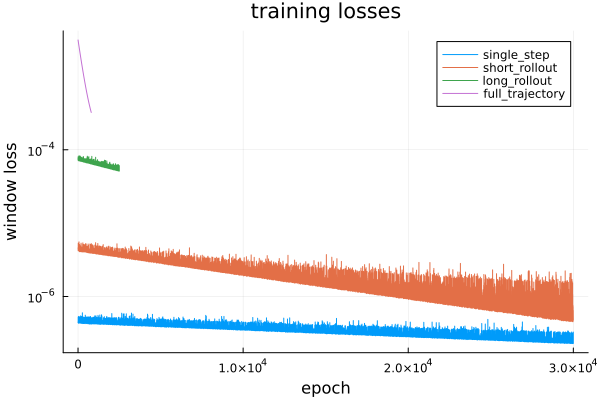

In [15]:
plot(title="training losses", xlabel="epoch", ylabel="window loss", yscale=:log10)
for key in [:single_step, :short_rollout, :long_rollout, :full_trajectory]
    plot!(training_errors[key], label=String(key))
end
plot!()


┌ Info: Saved animation to /var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_VovgB8XG1a.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_VovgB8XG1a.gif")
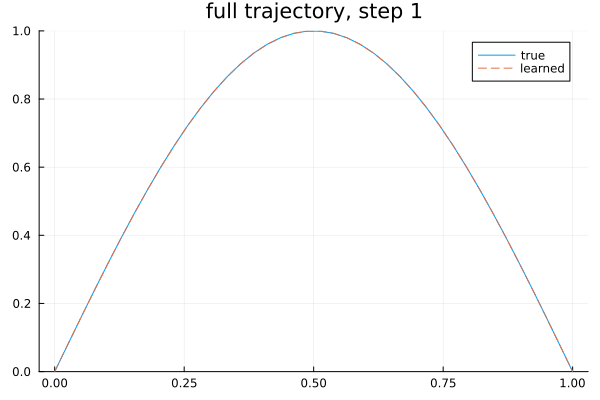

In [12]:
traj = stored_trajectories[:full_trajectory]
@gif for n in 1:2:size(traj.true_traj, 2)
    plot(x_train, traj.true_traj[:,n], label="true", ylim=(0,1), title="full trajectory, step $n")
    plot!(x_train, traj.learned[:,n], label="learned", linestyle=:dash)
end


# Results

Well, that's much better! To be honest, it took a lot of hyperparameter optimization; in particular, because my error has a factor of $\Delta t^2$ out front, I needed to increase my learning rates. But we (kinda) got there eventually. 